# 00 — Data Exploration
## Supplementary File Audit and Corpus Acquisition Planning

This notebook documents what is available in the Hom et al. (2022) supplementary files,
and outlines the data acquisition strategy for the DDx corpus.

**Key finding:** The supplementary files do NOT contain the actual DDx text.
The raw text must be acquired via author contact (Pathway A) or institutional NEJM access (Pathway C).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from pathlib import Path

DATA_DIR = Path('../appendix_datasets')
print('Dataset files:')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name:45s} {f.stat().st_size/1e6:.1f} MB')

Dataset files:
  .DS_Store                                     0.0 MB
  11606_2022_7758_MOESM2_ESM.pdf                0.1 MB
  11606_2022_7758_MOESM3_ESM.pdf                2.2 MB
  11606_2022_7758_MOESM4_ESM.pdf                0.6 MB
  11606_2022_7758_MOESM5_ESM.xlsx               0.0 MB
  11606_2022_7758_MOESM6_ESM.xlsx               0.0 MB
  11606_2022_7758_MOESM7_ESM.xlsx               0.1 MB
  11606_2022_7758_MOESM8_ESM.csv                30.4 MB
  Appendix Methods.pdf                          0.1 MB


## 1. Supplementary File Inventory

| File | Type | Content | Useful for this project? |
|---|---|---|---|
| MOESM2 (61KB PDF) | Methods | Appendix Methods — scraper description | YES — documents Pathway C methodology |
| MOESM3 (2.1MB PDF) | Figure | LDA category word maps (Fig 2A/2B) | Partial — confirms 12 LDA categories |
| MOESM4 (600KB PDF) | Figure | Correlation visualization | No |
| MOESM5 (12KB xlsx) | Table | Top 10 final diagnoses with case counts | Metadata only |
| MOESM6 (12KB xlsx) | Table | Top 50 symptoms with counts | Metadata only |
| MOESM7 (114KB xlsx) | Table | Symptom-symptom correlations (1,226 pairs) | Metadata only |
| MOESM8 (30MB csv) | Data | Symptom-diagnosis associations (300K rows) | Statistical metadata only |

**Conclusion: No DDx text is present in any supplementary file.**
The structured database (symptoms, diagnoses, categories) is the only publicly shared artifact.

In [3]:
# === MOESM5: Top diagnoses ===
wb5 = openpyxl.load_workbook(DATA_DIR / '11606_2022_7758_MOESM5_ESM.xlsx')
ws5 = wb5.active
diagnoses_data = list(ws5.iter_rows(values_only=True))
df_dx = pd.DataFrame(diagnoses_data[1:], columns=diagnoses_data[0])
print('Top 10 Final Diagnoses in NEJM CPC corpus:')
print(df_dx.to_string(index=False))

Top 10 Final Diagnoses in NEJM CPC corpus:
                       Med_term  case_count
     mycobacterium tuberculosis          78
             pulmonary embolism          74
          myocardial infarction          71
lymphoma, large b-cell, diffuse          50
                          hiv-1          47
                hodgkin disease          43
    endocarditis, non-infective          41
        endocarditis, bacterial          37
               brain infarction          36
               multiple myeloma          35


In [4]:
# === MOESM6: Top symptoms ===
wb6 = openpyxl.load_workbook(DATA_DIR / '11606_2022_7758_MOESM6_ESM.xlsx')
ws6 = wb6.active
sx_data = list(ws6.iter_rows(values_only=True))
df_sx = pd.DataFrame(sx_data[1:], columns=['Rank', 'Symptom', 'Count', 'Percent'])
df_sx['Percent'] = df_sx['Count'] / 2525  # compute from counts
print('Top 50 Symptoms in NEJM CPC corpus (first 15):')
print(df_sx.head(15).to_string(index=False))

Top 50 Symptoms in NEJM CPC corpus (first 15):
 Rank         Symptom  Count  Percent
    1            pain   1467 0.580990
    2        weakness    987 0.390891
    3           edema    871 0.344950
    4           fever    763 0.302178
    5         dyspnea    718 0.284356
    6           cough    686 0.271683
    7         fatigue    670 0.265347
    8        vomiting    628 0.248713
    9    hypertension    623 0.246733
   10     tachycardia    528 0.209109
   11          nausea    513 0.203168
   12 lymphadenopathy    484 0.191683
   13        headache    462 0.182970
   14  abdominal pain    449 0.177822
   15        anorexia    410 0.162376


In [5]:
# === MOESM8: Symptom-diagnosis associations ===
df_assoc = pd.read_csv(DATA_DIR / '11606_2022_7758_MOESM8_ESM.csv')
print(f'Shape: {df_assoc.shape}')
print(f'Columns: {df_assoc.columns.tolist()}')
print(f'Unique symptoms: {df_assoc["symptom"].nunique()}')
print(f'Unique diagnoses (MeSH): {df_assoc["Dx"].nunique()}')
print()
# Significant associations only
sig = df_assoc[df_assoc['FDR corrected p value'] < 0.05]
print(f'FDR-significant symptom-diagnosis pairs: {len(sig)}')
print()
print('Sample significant associations:')
print(sig.head(10).to_string(index=False))

Shape: (300135, 11)
Columns: ['Unnamed: 0', 'symptom', 'Dx', 's_idx', 'd_idx', 'Sx count', 'Dx count', 'p_value', 'PPV', 'NPV', 'FDR corrected p value']
Unique symptoms: 535
Unique diagnoses (MeSH): 561

FDR-significant symptom-diagnosis pairs: 2880

Sample significant associations:
 Unnamed: 0 symptom                                                              Dx  s_idx  d_idx  Sx count  Dx count      p_value      PPV      NPV  FDR corrected p value
          2    pain                                         Cardiovascular Diseases      0      2      1467       727 1.477680e-07 0.327198 0.768075           6.498809e-05
          3    pain                                               Vascular Diseases      0      3      1467       582 2.281792e-12 0.279482 0.838498           3.373624e-09
          5    pain                                    Hemic and Lymphatic Diseases      0      5      1467       531 2.081434e-04 0.235174 0.825352           2.605030e-02
          8    pain         

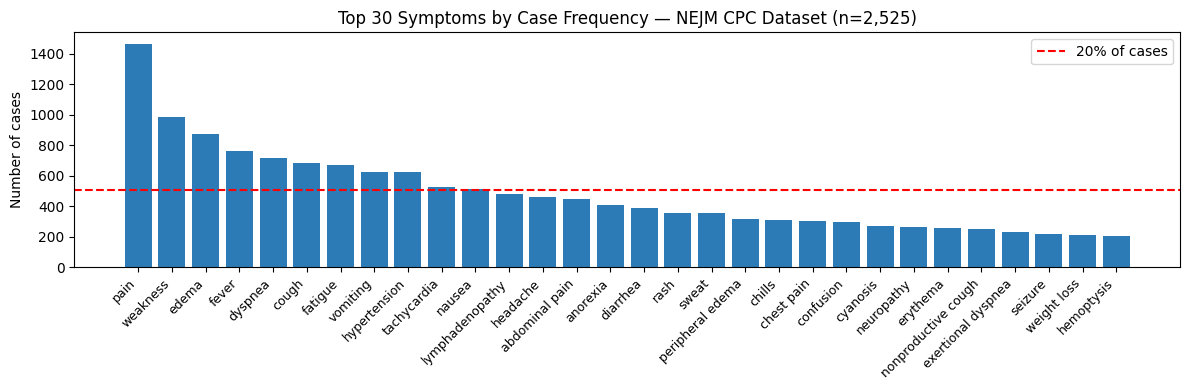

In [6]:
# === Symptom frequency distribution ===
# Get unique symptom counts from MOESM8
sx_counts = df_assoc.groupby('symptom')['Sx count'].first().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(min(30, len(sx_counts))), sx_counts.values[:30], color='#2c7bb6')
ax.set_xticks(range(min(30, len(sx_counts))))
ax.set_xticklabels(sx_counts.index[:30], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of cases')
ax.set_title('Top 30 Symptoms by Case Frequency — NEJM CPC Dataset (n=2,525)')
ax.axhline(2525 * 0.20, color='red', linestyle='--', label='20% of cases')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/eda_symptom_frequency.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 2. Appendix Methods Key Findings

From the Appendix Methods PDF (`MOESM2_ESM.pdf`):

### DDx Text Statistics
- **Total cases:** 2,532 (7 more than cited in main text — section parse failures explain the difference)
- **DDx word count:** mean 2,404 | min 145 | max 4,236
- **Mean medical terms per DDx:** 252 (min 10, max 568, median 245)
- **93%** of cases: final diagnosis confirmed by pathology/histology
- **7%** of cases: expert's clinical diagnosis used (when no pathology available)

### Acquisition Methodology (Pathway C blueprint)
The authors used:
- **Selenium** (Python) + **BeautifulSoup** for web scraping
- **After requesting explicit permission from NEJM** for this use
- Section splitting by structural article headers: `Presentation of Case`, `Differential Diagnosis`, `Final Diagnoses`

### Interface (UniverseofCPC.com)
- Built with R 3.5.3 + Rshiny
- Each case entry includes **a hyperlink to the original NEJM article** — this is the entry point for Pathway C

### LDA Topic Discovery
- **k=12** chosen as most stable and reproducible (tested k=10-20, 50, 100)
- 25 independent LDA solutions compared for stability using Hungarian algorithm
- Best solution by coherence selected as final model

## 3. Data Acquisition Strategy

### Pathway A (IMMEDIATE ACTION): Author contact
- Target: Timothy Zack and/or Lena Hom
- Request: pre-processed PoC/DDx/FD text splits
- Template: `../docs/data_access_request_template.md`
- Expected: 1–2 week turnaround for academic request

### Pathway B (PARALLEL): Explore UniverseofCPC.com
- The web interface has NEJM article hyperlinks per case
- If URLs are extractable from the interface, we have the URL list for Pathway C
- Tool: use Playwright MCP server to browse UniverseofCPC.com and extract case URLs

### Pathway C (FALLBACK): Institutional scraper
- Requires: USI institutional NEJM access OR NEJM permission
- Script: `../src/data/acquire.py` → `NEJMScraper` class
- Section splitter: `../src/data/parse.py` → `CPCParser`
- Note: Authors received explicit NEJM permission — we should request the same

### Pilot corpus (can start immediately)
While awaiting the full corpus, we can:
1. Find 10–20 publicly available NEJM CPC DDx sections online (some are open access or in preprints)
2. Use these for annotation guideline development and IAA Round 0
3. This does NOT require institutional access — only public-access CPCs

## 4. Next Steps Checklist

```
IMMEDIATE (Week 1):
[ ] Send data access request email to Hom/Zack authors
[ ] Browse UniverseofCPC.com to understand URL structure
[ ] Find 10-20 open-access NEJM CPCs for annotation pilot
[ ] Contact USI library about institutional NEJM access

WEEK 2–4 (pending author response):
[ ] If author data received: run load_author_provided() → preprocess → sample
[ ] If no response: use Playwright to extract NEJM URLs from UniverseofCPC.com
[ ] Begin annotation guideline calibration on pilot cases

PARALLEL (can do now):
[ ] Label Studio setup: run generate_config() and import to local instance
[ ] Assemble annotation team and distribute guidelines_v1.md
[ ] Install all requirements: pip install -r requirements.txt
```